In [1]:
list.of.packages <- c("tidyverse","data.table","sf","patchwork","ggpubr","stargazer","viridis","svglite","terra"
                      #,"RColorBrewer"#,"ggpattern","pals","purrr","ggrepel","hrbrthemes"
                     )
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivants sont masqués depuis ‘package:dplyr’:

    between, first, last


L'objet suivant est masqué depuis ‘package:purrr’:

    transpose


Linking to GEOS 3.14.1, GDAL 3.12.0, PROJ 9.7.0; sf_

## India shapefile

In [2]:
path_shp_india <- "./0_input/districts_borders/Census_2001/IND_adm0.shp"
india <- st_read(path_shp_india)

Reading layer `IND_adm0' from data source 
  `/diskdata/cired/lepault/V6_Heat_India_30_20_10/0_input/districts_borders/Census_2001/IND_adm0.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 70 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 68.18625 ymin: 6.754256 xmax: 97.41516 ymax: 35.50133
Geodetic CRS:  WGS 84


## District borders

In [3]:
#districts_2001 <- st_read( "./0A_input/districts_borders/Census_2001/IND_adm2.shp")

In [4]:
districts_2011 <- st_read( "./0_input/districts_borders/Census_2011/2011_Dist.shp")

Reading layer `2011_Dist' from data source 
  `/diskdata/cired/lepault/V6_Heat_India_30_20_10/0_input/districts_borders/Census_2011/2011_Dist.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 641 features and 5 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 68.18625 ymin: 6.755953 xmax: 97.41529 ymax: 37.07827
Geodetic CRS:  WGS 84


In [5]:
districts_2011_f <- districts_2011 %>%
                        filter(DISTRICT != "Data Not Available")
nrow(districts_2011_f)

[1] 640

# DHS Datasets

## Children

In [6]:
df_children <- read_csv("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

Rows: 281812 Columns: 362
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (11): State_2011, District_2011, Mother_id, Season, District_ID, T_i30...
dbl  (350): DHS_round, DHSCLUST, cell_x_01, cell_y_01, cell_x_025, cell_y_02...
date   (1): Measured_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "281812 rows x 362 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_height_for_age_zscore,Child_weight_for_age_zscore,Child_weight_for_height_zscore,Child_hemo_level_alti,Child_anemia_level,Child_female,Child_alive_age_month,Child_multiple_birth,Child_birth_order,Child_birth_order_1,Child_birth_weight,Child_born_winter,Child_born_summer,Child_born_kharif,Child_born_rabi,Child_diarrhea,Child_fever,Child_cough,Child_duration_breastfeeding,Child_ever_breastfed,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Child_vitA_supplem_6m,Child_deworming_med_6m,Child_any_antimalaria,Child_antimala_fansidar,Child_antimala_chloroquine,Child_antimala_quinine,Child_antimala_combi_artemisinin,Child_antimala_primaquin,Child_antimala_unknown,Child_antimala_other,Child_drug_aspirin,Child_drug_paracetamol,Child_drug_ibuprofen,Child_drug_antibiotic,Child_drug_other,Child_drug_nothing,Mother_current_age,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_hemo_level_alti,Mother_anemia_level,Mother_height,Usual_resident,Mother_away_sup1month,Bednet_slept,Bednet_slept_ITN,HH_Bednet,HH_water_dwelling,HH_water_yard_plot,HH_water_elsewhere,HH_time_water_source,HH_water_at_handwashing_place,HH_woman_fetching_water,HH_man_fetching_water,HH_female_child_fetching_water,HH_male_child_fetching_water,HH_air_conditioner,HH_treat_water,HH_well_water,HH_no_toilet,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Nd

## Men

In [7]:
df_men <- read_csv("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 150101 Columns: 361
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (14): State_2011, District_2011, Men_id, Age_group, Work_occup_cat, Pr...
dbl  (340): DHS_round, DHSCLUST, cell_x_01, cell_y_01, cell_x_025, cell_y_02...
lgl    (6): Partner_3, Partner_4, Partner_5, Partner_6, Partner_7, Partner_8
date   (1): Measured_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "150101 rows x 361 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Partner_1,Partner_2,Partner_3,Partner_4,Partner_5,Partner_6,Partner_7,Partner_8,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Literacy,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Smoker,Health_insurance,Work_currently_working,Work_occup_cat,Work_all_year,Work_season_occas,Work_not_paid,Work_paid_full_cash,Work_paid_cash_inkind,Work_paid_only_inkind,Arm_circonf,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Usual_resident,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Away_sup1month,Profession,Profession_agri,Blood_hemo_level_alti,Blood_anemia_level,Body_mass_index,Bednet_slept,Bednet_slept_ITN,HH_Bednet,HH_water_dwelling,HH_water_yard_plot,HH_water_elsewhere,HH_time_water_source,HH_water_at_handwashing_place,HH_woman_fetching_water,HH_man_fetching_water,HH_female_child_fetching_water,HH_male_child_fetching_water,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on

## Women

In [8]:
df_women <- read_csv("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

Rows: 973462 Columns: 354
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (13): State_2011, District_2011, Women_id, Age_group, Work_occup_cat, ...
dbl  (340): DHS_round, DHSCLUST, cell_x_01, cell_y_01, cell_x_025, cell_y_02...
date   (1): Measured_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "973462 rows x 354 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Partner,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Literacy,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Smoker,Currently_pregnant,Currently_breasfeeding,Health_insurance,Work_currently_working,Work_occup_cat,Work_all_year,Work_season_occas,Work_not_paid,Work_paid_full_cash,Work_paid_cash_inkind,Work_paid_only_inkind,Arm_circonf,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Blood_hemo_level_alti,Blood_anemia_level,Body_mass_index,Usual_resident,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Away_sup1month,Bednet_slept,Bednet_slept_ITN,HH_Bednet,HH_water_dwelling,HH_water_yard_plot,HH_water_elsewhere,HH_time_water_source,HH_water_at_handwashing_place,HH_woman_fetching_water,HH_man_fetching_water,HH_female_child_fetching_water,HH_male_child_fetching_water,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_N

# All individuals to plot DHS surveys seasons

In [9]:
df_all <- rbind(df_children%>%select(DHS_round,DHSCLUST,State_2011,District_2011,
                                     cell_x=cell_x_01,cell_y=cell_y_01,
                                     Interview_month,Interview_year),
                df_women%>%select(DHS_round,DHSCLUST,State_2011,District_2011,
                                  cell_x=cell_x_01,cell_y=cell_y_01,
                                  Interview_month,Interview_year),
                df_men%>%select(DHS_round,DHSCLUST,State_2011,District_2011,
                                cell_x=cell_x_01,cell_y=cell_y_01,
                                Interview_month,Interview_year)
               )
sprintf("%i rows x %i columns", nrow(df_all), ncol(df_all))
head(df_all,2)

[1] "1405375 rows x 8 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x,cell_y,Interview_month,Interview_year
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2015,10001,Andaman & Nicobar Island,South Andaman,92.7,11.7,7,2015
2015,10001,Andaman & Nicobar Island,South Andaman,92.7,11.7,7,2015


# Plots

In [10]:
df_DHS_season_long <- df_all %>%
                    mutate(Season = case_when(Interview_month %in% c(12,1,2) ~ "Winter",
                                              Interview_month %in% 3:5 ~ "Summer",
                                              Interview_month %in% 6:8 ~ "Kharif",
                                              TRUE ~ "Rabi"))%>%
                    group_by(cell_x,cell_y,Interview_year,Season)%>%
                    summarize(N=n())%>%
                    ungroup()
sprintf("%i x %i dataframe", nrow(df_DHS_season_long), ncol(df_DHS_season_long))
head(df_DHS_season_long,2)

`summarise()` has grouped output by 'cell_x', 'cell_y', 'Interview_year'. You can override using the `.groups` argument.


[1] "21645 x 5 dataframe"

cell_x,cell_y,Interview_year,Season,N
<dbl>,<dbl>,<dbl>,<chr>,<int>
68.8,23.3,2016,Summer,53
69.0,22.3,2019,Kharif,52


In [11]:
df_DHS_season <- df_DHS_season_long%>%
                    mutate(N_cat = ifelse(N<25,"(1,25(",
                                             ifelse(N>=25 & N<50,"(25,50(",
                                               ifelse(N>=50 & N<100,"(50,100(",">100"))))%>%
                    select(-N)%>%
                    pivot_wider(names_from=Season, values_from=N_cat)
sprintf("%i x %i dataframe", nrow(df_DHS_season), ncol(df_DHS_season))
head(df_DHS_season,2)

[1] "19111 x 7 dataframe"

cell_x,cell_y,Interview_year,Summer,Kharif,Rabi,Winter
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
68.8,23.3,2016,"(50,100(",NA,NA,NA
69.0,22.3,2019,NA,"(50,100(",NA,NA


In [12]:
theme_map_DHS <- function(...) {
  # On part du theme minimal, qui existe déjà
  # on retire juste les axes
  theme(
    title = element_text(size = 24),
    axis.line = element_blank(),
    axis.ticks = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 16),
    legend.key.size = unit(2, "cm"),
    strip.text.x = element_text(size = 20),
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    panel.background = element_rect(fill = "aliceblue"),
  )
}

In [13]:
plot_season <- function(df,col,season_name){
            plot <- ggplot() +
                       geom_tile(data = df,
                                      aes(x = cell_x, y = cell_y, fill = col)) + 
                       coord_quickmap()+
                       facet_wrap(~Interview_year,nrow=4)+
                       scale_fill_manual(values = c('#440154FF','#35B779FF','orange','red'),#3 of viridis(4),
                                          na.value="white",
                                          labels=c("(1,25(","(25,50(","(50,100(",">100",""))+
                       geom_sf(data = india,fill=NA, color="black", lwd=0.2, alpha=0.9)+
                       geom_sf(data = districts_2011_f,fill=NA, color="black", lwd=0.1, alpha=0.9)+
                       labs(title= season_name, fill = "Number of individuals") +
                       theme_map_DHS()
            return(plot)
}

In [14]:
DHS_winter <- plot_season(df_DHS_season,df_DHS_season$Winter,"Winter")

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


In [15]:
DHS_summer <- plot_season(df_DHS_season,df_DHS_season$Summer,"Summer")

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


In [16]:
DHS_kharif <- plot_season(df_DHS_season,df_DHS_season$Kharif,"Kharif")

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


In [17]:
DHS_rabi <- plot_season(df_DHS_season,df_DHS_season$Rabi,"Rabi")

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


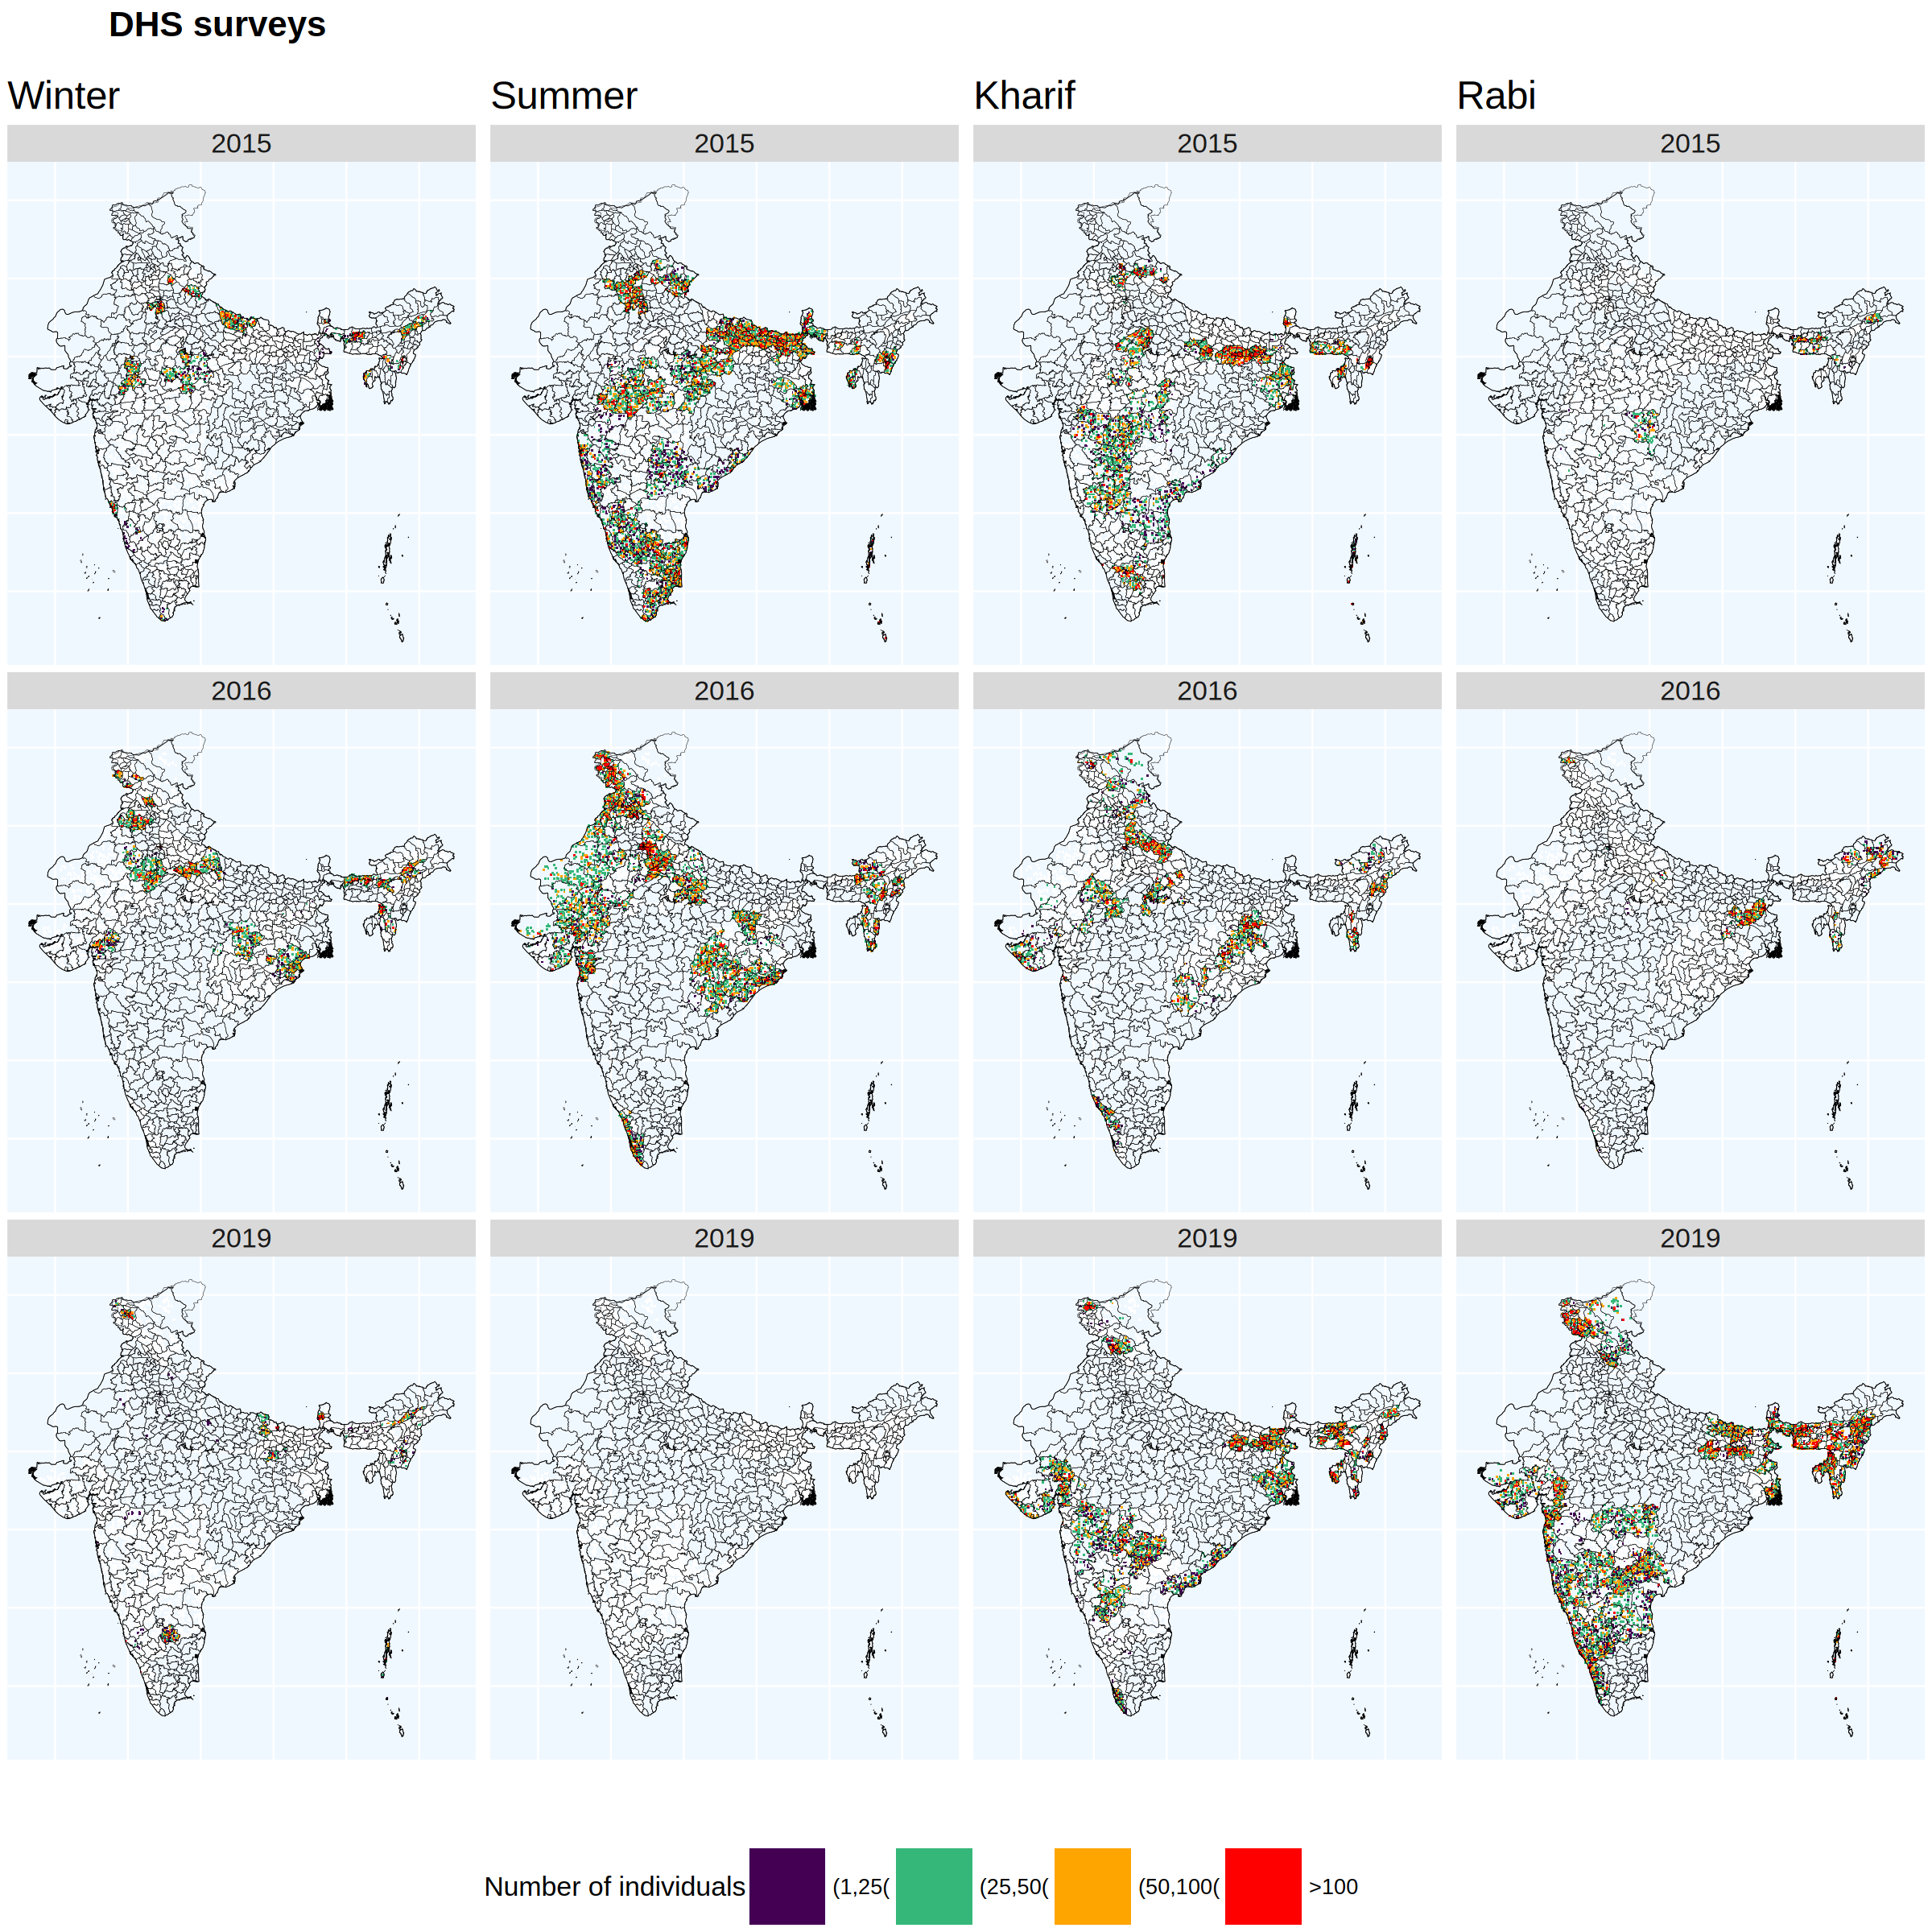

In [18]:
options(repr.plot.width=20, repr.plot.height=20, scipen=9999)

plot_maps_DHS <- ggarrange(DHS_winter, DHS_summer,DHS_kharif, DHS_rabi,
                           labels = c("DHS surveys", "","",""),
                           font.label = list(size = 26),
                           common.legend = TRUE, legend = "bottom", ncol=4, nrow = 1)
plot_maps_DHS

In [19]:
ggsave("./3_output/img/maps_DHS_seasons.png", width=26, height=24, units="in", plot_maps_DHS)